# 08 · One Problem, Many Algorithms

    [Course README](../README.md) · Created by Shivam Bharadwaj

    [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/08_one_problem_many_algorithms.ipynb)

    **Goal:** Compare planning, prediction, and control without changing the environment or hiding unequal assumptions.

    Restart the kernel and run all cells. Local setup: install the root
    `requirements.txt` first. On Colab, the setup cell clones the public course
    code into the runtime.
    Readable implementation modules live in `rl_course/`; links below connect each experiment to its source.
    Code is MIT licensed; explanations and plots are CC BY 4.0. See the root LICENSE.

In [1]:
import sys, subprocess
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd() if (Path.cwd() / 'rl_course').exists() else Path.cwd().parent
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course').exists():
    raise FileNotFoundError('Clone the complete repository and open this notebook from its notebooks directory.')
if IN_COLAB and False:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(ROOT / 'requirements-modern.txt')], check=True)
sys.path.insert(0, str(ROOT))
import platform, numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline
torch.set_num_threads(2)
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({'figure.figsize': (10, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'text.color': INK,
    'axes.labelcolor': INK, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
                     '\n'.join('| ' + ' | '.join(str(value).replace('|', '&#124;').replace('\n', '<br>') for value in row) + ' |' for row in rows)))
print(f'Python {platform.python_version()} | NumPy {np.__version__} | PyTorch {torch.__version__} | CPU, 2 threads')

Python 3.12.4 | NumPy 2.5.3 | PyTorch 2.11.0+cpu | CPU, 2 threads


## 1. The experimental contract

**DeliveryLine-v1:** a robot starts at position 2 on a five-position line. The destination
is 0 or 4, chosen equally at reset and observed by the policy. Every episode lasts exactly
six moves. Each move costs 0.01; being at the destination after move six adds 1.
The observation includes position, destination, and time remaining. Gamma is 1.

**Analogy:** every courier gets the same six-move shift. A planner gets the town map;
the learners must discover useful behavior through trips. A predictor only estimates
the performance of an existing courier—it is not competing for the best route.

Source: [comparison.py](../rl_course/comparison.py). Read `transition`, `evaluate`, then each trainer.

| Track | Methods | Report | Information available |
|---|---|---|---|
| Planning | Backward dynamic programming | Optimal return, model backups, time | Exact transition/reward model |
| Prediction | First-visit MC, TD(0) | Value RMSE over reachable states | Same random-policy trajectories |
| Control | MC control, SARSA, Q-learning, DQN, REINFORCE, actor-critic, PPO | Return vs interactions, final seed spread, time | Sampled transitions only |

DP is an oracle baseline, not a zero-sample learning winner. MC and TD prediction do not
produce control policies. MC **control** is additionally included for a meaningful control comparison.

In [2]:
from time import perf_counter
from rl_course import comparison as lab
SEEDS, EPISODES = (7, 19, 31), 600
started = perf_counter()
v_star = lab.evaluate()
planning_seconds = perf_counter() - started
optimal = v_star[lab.STARTS].mean()
random_value = lab.evaluate(np.full((lab.N_STATES, 2), .5))[lab.STARTS].mean()
assert np.isclose(optimal, .94)
assert lab.transition(lab.TERMINAL, 0) == (lab.TERMINAL, 0., True)
assert all(lab.transition(lab.encode(5, p, g), a)[2] for p in range(5) for g in range(2) for a in range(2))
table(['Environment', 'Seeds', 'Episodes/run', 'Transitions/run', 'Gamma'],
      [[lab.ENV_VERSION, SEEDS, EPISODES, EPISODES * lab.HORIZON, 1]])
table(['Planner', 'Optimal return', 'State-action backups', 'Seconds'],
      [['Backward DP', f'{optimal:.3f}', 60 * 2, f'{planning_seconds:.5f}']])
print(f'Exact random-policy expected return: {random_value:.3f}')

| Environment | Seeds | Episodes/run | Transitions/run | Gamma |
|---|---|---|---|---|
| DeliveryLine-v1 | (7, 19, 31) | 600 | 3600 | 1 |

| Planner | Optimal return | State-action backups | Seconds |
|---|---|---|---|
| Backward DP | 0.940 | 120 | 0.00013 |

Exact random-policy expected return: 0.174


## 2. Prediction: estimate a fixed policy before trying to improve it

Each seed supplies paired random-policy episodes to both predictors. MC uses sample averages;
TD uses step size 0.1. This is a comparison of these settings, not proof that one method
universally has lower error. The analytic evaluator supplies the independent ground truth.

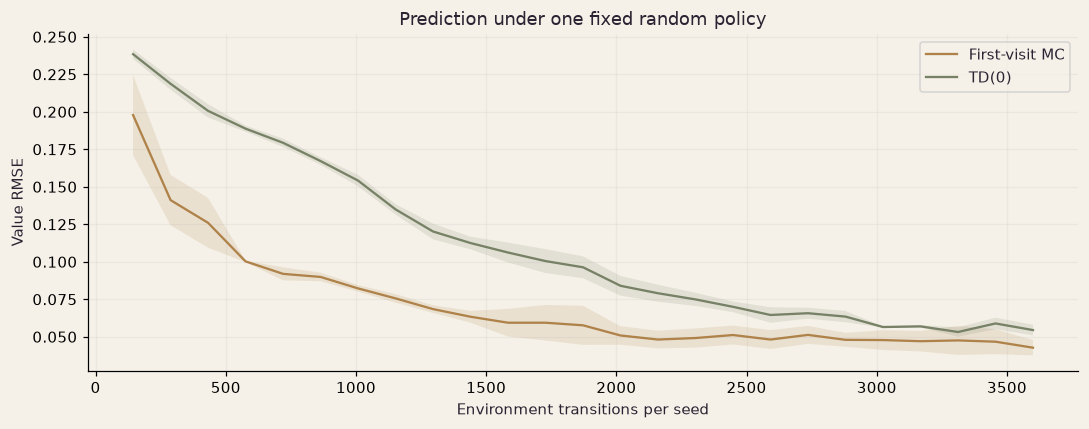

| Predictor | Final RMSE mean | Final RMSE SD |
|---|---|---|
| MC | 0.0427 | 0.0088 |
| TD(0) | 0.0545 | 0.0062 |

In [3]:
prediction = [lab.prediction(seed, EPISODES) for seed in SEEDS]
fig, ax = plt.subplots()
for column, label in [(1, 'First-visit MC'), (2, 'TD(0)')]:
    curves = np.array([run['history'][:, column] for run in prediction])
    mean, se = curves.mean(0), curves.std(0, ddof=1) / np.sqrt(len(SEEDS))
    x = prediction[0]['history'][:, 0]
    ax.plot(x, mean, label=label); ax.fill_between(x, mean-se, mean+se, alpha=.15)
ax.set(xlabel='Environment transitions per seed', ylabel='Value RMSE', title='Prediction under one fixed random policy')
ax.legend(); plt.tight_layout(); plt.show()
table(['Predictor', 'Final RMSE mean', 'Final RMSE SD'],
      [[label, f'{np.mean([r["history"][-1, c] for r in prediction]):.4f}',
        f'{np.std([r["history"][-1, c] for r in prediction], ddof=1):.4f}']
       for c, label in [(1, 'MC'), (2, 'TD(0)')]])
assert all(np.isfinite(run['history']).all() for run in prediction)

## 3. Control: equal interaction budget, explicit update differences

All seven controllers receive 3,600 transitions per seed. Tabular and DQN evaluation is greedy;
policy-gradient evaluation uses the learned stochastic policy. Exact model evaluation introduces
no action-sampling noise and never updates a learner. Timings include periodic evaluation,
exclude imports, and depend on hardware. Equal interactions do **not** imply equal compute.

| Method | Behavior/target relationship | Main settings |
|---|---|---|
| MC control | On-policy sampled returns | Sample averages, epsilon 0.8 → 0.08 |
| SARSA | On-policy next action | Alpha .25, same epsilon schedule |
| Q-learning | Off-policy greedy bootstrap | Alpha .25, same epsilon schedule |
| DQN | Off-policy replay and greedy bootstrap | Adam .003, batch 64, replay 3,000, target copy every 120 steps |
| REINFORCE | On-policy complete returns | 24 episodes/update, Adam .01, entropy .01 |
| Actor-Critic | On-policy one-step TD advantage | 24 episodes/update, Adam .01, value weight .5 |
| PPO | Recent on-policy rollout reused | 24 episodes/update, 4 epochs, Adam .004, lambda .95, clip .2 |

These settings were selected for a small teaching task, not tuned with held-out benchmark suites.
The neural models use 32 hidden units; tabular methods use discrete time-indexed states.

Training MC control ...


Training SARSA ...


Training Q-learning ...


Training DQN ...


Training REINFORCE ...


Training Actor-Critic ...


Training PPO ...


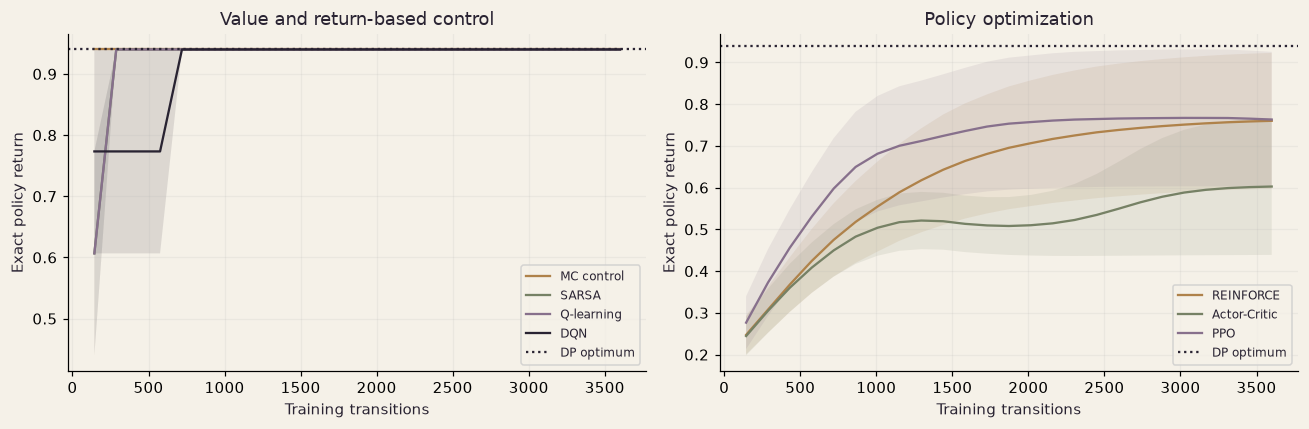

| Method | Final return mean | Seed SD | Steps to 90% success / seed (None=not reached) | Peak-to-final drop | Mean seconds |
|---|---|---|---|---|---|
| MC control | 0.940 | 0.000 | [144, 144, 144] | 0.000 | 0.04 |
| SARSA | 0.940 | 0.000 | [288, 288, 144] | 0.000 | 0.04 |
| Q-learning | 0.940 | 0.000 | [288, 288, 144] | 0.000 | 0.04 |
| DQN | 0.940 | 0.000 | [144, 720, 144] | 0.000 | 3.46 |
| REINFORCE | 0.760 | 0.282 | [None, 2016, 1728] | 0.000 | 1.16 |
| Actor-Critic | 0.603 | 0.284 | [None, 2880, None] | 0.038 | 1.16 |
| PPO | 0.763 | 0.281 | [None, 1584, 1008] | 0.005 | 1.27 |

In [4]:
runs = lab.run_control(SEEDS, EPISODES)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (method, records) in enumerate(runs.items()):
    ax = axes[0 if i < 4 else 1]
    curves = np.array([r['history'][:, 1] for r in records])
    mean, se = curves.mean(0), curves.std(0, ddof=1) / np.sqrt(len(SEEDS))
    x = records[0]['history'][:, 0]
    ax.plot(x, mean, label=method); ax.fill_between(x, mean-se, mean+se, alpha=.12)
    assert np.isfinite(curves).all() and curves.max() <= optimal + 1e-6
for ax in axes:
    ax.axhline(optimal, color=INK, linestyle=':', label='DP optimum')
    ax.set(xlabel='Training transitions', ylabel='Exact policy return'); ax.legend(fontsize=8)
axes[0].set_title('Value and return-based control'); axes[1].set_title('Policy optimization')
plt.tight_layout(); plt.show()
rows = []
for method, records in runs.items():
    curves = np.array([r['history'][:, 1] for r in records])
    # First measured checkpoint at 90% success (return .84); no interpolation.
    hits = [next((int(x) for x, y in r['history'] if y >= .84), None) for r in records]
    regressions = (curves.max(1) - curves[:, -1]).mean()
    rows.append([method, f'{curves[:, -1].mean():.3f}', f'{curves[:, -1].std(ddof=1):.3f}',
                 str(hits), f'{regressions:.3f}', f'{np.mean([r["seconds"] for r in records]):.2f}'])
table(['Method', 'Final return mean', 'Seed SD', 'Steps to 90% success / seed (None=not reached)',
       'Peak-to-final drop', 'Mean seconds'], rows)

## 4. Read the experiment without inventing a leaderboard

**Sample efficiency:** inspect return at equal transition counts and the threshold column.
**Stability:** inspect regressions and variation across seeds. **Convergence:** proximity to
the DP answer is evidence on this finite task, not an asymptotic convergence proof.
Seed SD measures variation across runs, not the variance of a policy-gradient estimator.
The small number of seeds supports exploration, not strong statistical claims.

**Failure Mode — sparse reward:** increasing the horizon or requiring a precise route can
make successful episodes rare. A method that wins here may fail when its exploration no longer finds feedback.

## Exercises and knowledge checks

1. Why is DP excluded from the sample-efficiency ranking? Explain the information advantage.
2. Why can the two prediction methods share episodes while controllers cannot generally share their own on-policy trajectories?
3. Add Double DQN by using the online network to select the bootstrap action and the target to evaluate it.
4. Run ten seeds and vary one hyperparameter at a time. Report every run, including failures.
5. Replace deterministic moves with stochastic slips. Update both simulator and evaluation model; verify they agree.

<details><summary>Expected reasoning</summary>

DP reads dynamics that learners do not receive. On-policy targets depend on the collector's policy.
Double DQN separates selection from evaluation but does not guarantee better returns on this easy task.
Model/simulator disagreement invalidates the exact evaluator.

</details>

References: [Sutton & Barto, Chapters 4–6 and 13](http://incompleteideas.net/book/the-book-2nd.html),
[DQN](https://doi.org/10.1038/nature14236), [PPO](https://arxiv.org/abs/1707.06347).

[Next: a real small-model post-training lab →](09_small_model_sft_dpo.ipynb)